# **Case QuantumFinance - Disciplina Generative AI - Classificador de chamados**

**Atenção:**
- Leia com atenção o descritivo do trabalho e as orientações do template.
- O trabalho deve ser entregue respeitando a estrutura do arquivo de template em notebook "Template_Trabalho_Final_Generative_AI.ipynb" e compactado no formato .zip. Apenas um arquivo no formato .ipynb deve ser entregue consolidando todo o trabalho.

***Participantes (RM - NOME):***<br>
RM361325 - Américo Travassos Soares Silva<br>
RM360558 - Douglas Cassiano Rodrigues Paes<br>
RM362209 - Eleric Escaleira Fuzinato<br>
RM362352 - Eroilton Borges Junior<br>

## Atividade 1

###**Crie um classificador de chamados aplicando técnicas de Prompt Engineering e RAG**
---

A **QuantumFinance** tem um canal de atendimento via chat e precisar classificar os assuntos dos atendimentos para melhorar as tratativas dos chamados dos clientes. O canal recebe textos abertos dos clientes relatando o problema e/ou dúvida e depois é direcionado para alguma área especialista no assunto para uma melhor tratativa.​


1. Você deverá aplicar técnicas de Engenharia de prompt para fazer um classificador de assuntos que consiga classificar através de um texto o assunto conforme disponível na base de dados [1] para treinamento e validação do seu modelo.​

2. Utilizar Técnicas de RAG a fim de melhorar a qualidade do classificador. Neste caso o RAG deverá buscar textos similares aos existentes no dataset e adicioná-los automaticamente no prompt como exemplo

3. Compare os resultados obtidos em cada etapa e também com relação aos resultados obtidos na disciplina de NLP.

**Observações Importantes:**

- Para evitar custos excessivos, utilize um subset pequeno durante a fase de desenvolvimento da solução. Para a entrega final, faça uma amostragem estratificada do dataset original com 50 exemplos de cada categoria.

- Tome cuidado para não utilizar o dataset de teste em nenhuma atividade no desenvolvimento do modelo.

**Composição da nota:​**

**50%** - Demonstrações das aplicações das técnicas de PLN (regras, pré-processamentos, tratamentos, variedade de modelos aplicados, organização do pipeline, etc.)​

**50%** - Baseado na performance (score) obtida com a amostra de teste no pipeline do modelo campeão (validar com  a Métrica F1 Score). **Separar o pipeline completo do modelo campeão conforme template.​**

O trabalho poderá ser feito em grupo de 2 até 5 pessoas (mesmo grupo do Startup One) e trabalhos iguais serão descontado nota e passível de reprovação.

**[1] = ​https://dados-ml-pln.s3.sa-east-1.amazonaws.com/tickets_reclamacoes_classificados.csv**

**[F1 Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)** com average='weighted'

Bom desenvolvimento!

## Setup do ambiente

In [1]:
# Se precisar instalar no ambiente
!pip install -q numpy pandas scikit-learn matplotlib tqdm openai requests

In [2]:
# Importações
import os
import re
import json
import random
import warnings
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from openai import OpenAI

warnings.filterwarnings("ignore")

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Controles principais

In [3]:
DEV_MODE = False         # True: usa subconjuntos menores para desenvolvimento
RUN_LLM = True           # False: executa somente baseline NLP

# seletor hibrido solicitado
LLM_DEFINITION = "ollama"   # "ollama" ou "openai"

OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")

OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "gpt-oss-safeguard:20b")
OLLAMA_URL = os.getenv("OLLAMA_URL", "http://localhost:11434/api/generate")

# limite de avaliacoes com LLM para reduzir custo
LLM_MAX_VAL_SAMPLES_DEV = 30
LLM_MAX_TEST_SAMPLES_DEV = 30
RAG_TOP_K = 4

DATA_URL = "https://dados-ml-pln.s3.sa-east-1.amazonaws.com/tickets_reclamacoes_classificados.csv"
NLP_CHAMPION_PATH = Path("champion_pipeline.joblib")

print("Configuracao carregada.")
print(f"DEV_MODE={DEV_MODE} | RUN_LLM={RUN_LLM} | LLM_DEFINITION={LLM_DEFINITION}")

Configuracao carregada.
DEV_MODE=False | RUN_LLM=True | LLM_DEFINITION=ollama


## Carregando o dataset

In [4]:
df = pd.read_csv(DATA_URL, delimiter=";")
print("Shape original:", df.shape)
print("Colunas:", list(df.columns))

text_col = "descricao_reclamacao"
target_col = "categoria"

print(f"text_col={text_col} | target_col={target_col}")

df = df[[text_col, target_col]].dropna().copy()
df[text_col] = df[text_col].astype(str)
df[target_col] = df[target_col].astype(str).str.strip()

print("Shape apos limpeza:", df.shape)
print("Classes e contagens:")
display(df[target_col].value_counts())

Shape original: (21072, 4)
Colunas: ['id_reclamacao', 'data_abertura', 'categoria', 'descricao_reclamacao']
text_col=descricao_reclamacao | target_col=categoria
Shape apos limpeza: (21072, 2)
Classes e contagens:


categoria
Serviços de conta bancária             5161
Cartão de crédito / Cartão pré-pago    5006
Roubo / Relatório de disputa           4822
Hipotecas / Empréstimos                3850
Outros                                 2233
Name: count, dtype: int64

In [5]:
# Funções utilitárias de limpeza

def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"\s+", " ", text)
    return text

# Aplica preprocessamento

df["text_clean"] = df[text_col].map(clean_text)

# Requisito da entrega: 50 por categoria
class_counts = df[target_col].value_counts()
if (class_counts < 50).any():
    few = class_counts[class_counts < 50]
    raise ValueError(f"Ha classes com menos de 50 exemplos: {few.to_dict()}")

final_subset = (
    df.groupby(target_col, group_keys=False)
      .sample(n=50, random_state=SEED)
      .reset_index(drop=True)
)

print("Amostra final estratificada:", final_subset.shape)
display(final_subset[target_col].value_counts())

# Split sem vazamento: treino/validação/teste
# 60/20/20 com estratificação

train_df, test_df = train_test_split(
    final_subset,
    test_size=0.20,
    random_state=SEED,
    stratify=final_subset[target_col]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=SEED,
    stratify=train_df[target_col]
)

print(f"Split final -> train={len(train_df)} | val={len(val_df)} | test={len(test_df)}")

if DEV_MODE:
    # Subconjuntos reduzidos para diminuir custo na fase de desenvolvimento
    train_df_dev = train_df.groupby(target_col, group_keys=False).apply(
        lambda x: x.sample(n=min(20, len(x)), random_state=SEED)
    ).reset_index(drop=True)

    val_df_dev = val_df.groupby(target_col, group_keys=False).apply(
        lambda x: x.sample(n=min(10, len(x)), random_state=SEED)
    ).reset_index(drop=True)

    test_df_dev = test_df.groupby(target_col, group_keys=False).apply(
        lambda x: x.sample(n=min(10, len(x)), random_state=SEED)
    ).reset_index(drop=True)

    train_df, val_df, test_df = train_df_dev, val_df_dev, test_df_dev
    print("DEV_MODE ativo: usando subconjuntos menores")
    print(f"Novo split -> train={len(train_df)} | val={len(val_df)} | test={len(test_df)}")

LABELS = sorted(train_df[target_col].unique().tolist())
DEFAULT_LABEL = train_df[target_col].value_counts().idxmax()

print("Numero de classes:", len(LABELS))
print("Default label (fallback):", DEFAULT_LABEL)


Amostra final estratificada: (250, 3)


categoria
Cartão de crédito / Cartão pré-pago    50
Hipotecas / Empréstimos                50
Outros                                 50
Roubo / Relatório de disputa           50
Serviços de conta bancária             50
Name: count, dtype: int64

Split final -> train=150 | val=50 | test=50
Numero de classes: 5
Default label (fallback): Serviços de conta bancária


## Baselines de NLP

In [6]:
def weighted_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="weighted")

baseline_models = {
    "TFIDF + MultinomialNB": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
        ("clf", MultinomialNB())
    ]),
    "TFIDF + LogisticRegression": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
        ("clf", LogisticRegression(max_iter=3000, random_state=SEED))
    ]),
    "TFIDF + LinearSVC": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
        ("clf", LinearSVC())
    ])
}

baseline_fitted = {}
baseline_val_rows = []

for name, model in baseline_models.items():
    model.fit(train_df["text_clean"], train_df[target_col])
    pred_val = model.predict(val_df["text_clean"])
    f1_val = weighted_f1(val_df[target_col], pred_val)
    baseline_fitted[name] = model
    baseline_val_rows.append((name, f1_val))

baseline_val_df = pd.DataFrame(baseline_val_rows, columns=["abordagem", "f1_weighted_val"]).sort_values("f1_weighted_val", ascending=False)
display(baseline_val_df)

best_baseline_name = baseline_val_df.iloc[0]["abordagem"]
best_baseline = baseline_fitted[best_baseline_name]

print("Melhor baseline NLP:", best_baseline_name)


,abordagem,f1_weighted_val
2,TFIDF + LinearSVC,0.730679
1,TFIDF + LogisticRegression,0.729762
0,TFIDF + MultinomialNB,0.565382


Melhor baseline NLP: TFIDF + LinearSVC


## Comparacao com champion pipeline da disciplina de NLP

In [7]:
nlp_champion_available = NLP_CHAMPION_PATH.exists()
nlp_champion_f1_val = None
nlp_champion_f1_test = None

if nlp_champion_available:
    import joblib
    try:
        nlp_champion = joblib.load(NLP_CHAMPION_PATH)

        # tentativa 1: texto limpo
        pred_val = nlp_champion.predict(val_df["text_clean"])
        pred_test = nlp_champion.predict(test_df["text_clean"])

        nlp_champion_f1_val = weighted_f1(val_df[target_col], pred_val)
        nlp_champion_f1_test = weighted_f1(test_df[target_col], pred_test)
        print("Champion NLP carregado com sucesso usando text_clean")
    except Exception:
        try:
            # tentativa 2: texto original
            pred_val = nlp_champion.predict(val_df[text_col])
            pred_test = nlp_champion.predict(test_df[text_col])

            nlp_champion_f1_val = weighted_f1(val_df[target_col], pred_val)
            nlp_champion_f1_test = weighted_f1(test_df[target_col], pred_test)
            print("Champion NLP carregado com sucesso usando texto original")
        except Exception as e:
            print("Não foi possivel avaliar champion_pipeline.joblib:", repr(e))
else:
    print("Arquivo champion_pipeline.joblib Não encontrado. Etapa sera ignorada.")

print("nlp_champion_available:", nlp_champion_available)

Champion NLP carregado com sucesso usando text_clean
nlp_champion_available: True


## Funcoes para chamada de LLM (OpenAI ou Ollama)

In [8]:
# Funcao para extrair label da resposta do LLM, tentando JSON e fallback de texto
def parse_label_from_response(raw_text: str, labels: list[str]) -> str | None:
    if not raw_text:
        return None

    # tenta JSON direto
    try:
        obj = json.loads(raw_text)
        label = str(obj.get("classe", "")).strip()
        if label in labels:
            return label
    except Exception:
        pass

    # tenta extrair JSON dentro de texto
    m = re.search(r"\{[\s\S]*\}", raw_text)
    if m:
        try:
            obj = json.loads(m.group(0))
            label = str(obj.get("classe", "")).strip()
            if label in labels:
                return label
        except Exception:
            pass

    # fallback: procura label literal na resposta
    raw_cf = raw_text.casefold()
    for lb in labels:
        if lb.casefold() in raw_cf:
            return lb

    return None

# Funcao unificada para chamada de LLM, com suporte a OpenAI e Ollama
def call_llm(prompt: str, temperature: float = 0.0, max_tokens: int = 120) -> str:
    provider = LLM_DEFINITION.strip().lower()

    if provider == "openai":
        if not OPENAI_API_KEY:
            raise RuntimeError("OPENAI_API_KEY Não definido.")
        from openai import OpenAI

        client = OpenAI(api_key=OPENAI_API_KEY)
        resp = client.chat.completions.create(
            model=OPENAI_MODEL,
            temperature=temperature,
            max_tokens=max_tokens,
            messages=[
                {
                    "role": "system",
                    "content": "Você classifica chamados. Responda somente JSON válido no formato {\"classe\": \"...\"}."
                },
                {"role": "user", "content": prompt}
            ]
        )
        return (resp.choices[0].message.content or "").strip()

    if provider == "ollama":
        import requests
        payload = {
            "model": OLLAMA_MODEL,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": temperature,
                "num_predict": max_tokens
            }
        }
        r = requests.post(OLLAMA_URL, json=payload, timeout=120)
        r.raise_for_status()
        return r.json().get("response", "").strip()

    raise ValueError("LLM_DEFINITION deve ser 'openai' ou 'ollama'.")

# função para construir exemplos few-shot a partir do conjunto de treino, garantindo um exemplo por classe
def build_fewshot_examples(train_frame: pd.DataFrame, labels: list[str]) -> list[dict]:
    examples = []
    for lb in labels:
        ex = train_frame[train_frame[target_col] == lb].iloc[0]
        examples.append({"text": ex["text_clean"], "classe": lb})
    return examples

fewshot_examples = build_fewshot_examples(train_df, LABELS)

#Função para construir o prompt few-shot a partir do texto do usuário, das classes e dos exemplos
def build_prompt_fewshot(user_text: str, labels: list[str], examples: list[dict]) -> str:
    labels_str = ", ".join([f'"{x}"' for x in labels])
    examples_str = "\n".join([f"- Texto: {e['text']}\n  Classe: {e['classe']}" for e in examples])

    return f"""Tarefa: classificar o assunto de um chamado de atendimento da QuantumFinance.

Regras:
1) Escolha exatamente uma classe da lista permitida.
2) Não invente classes.
3) Responda APENAS em JSON válido.

Classes permitidas: [{labels_str}]

Exemplos:
{examples_str}

Chamado do cliente:
{user_text}

Saída esperada:
{{"classe": "<uma classe permitida>"}}"""

## RAG: recuperacao de exemplos similares apenas no treino

In [9]:
# RAG setup
rag_ref = train_df[["text_clean", target_col]].reset_index(drop=True).copy()
rag_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
X_rag = rag_vectorizer.fit_transform(rag_ref["text_clean"])

# Função para recuperar os k exemplos mais similares do conjunto de treino usando TF-IDF + cosseno
def retrieve_similar(text: str, k: int = 4) -> pd.DataFrame:
    q = rag_vectorizer.transform([text])
    sims = cosine_similarity(q, X_rag).ravel()
    idx = np.argsort(-sims)[:k]
    out = rag_ref.iloc[idx].copy()
    out["similarity"] = sims[idx]
    return out

# Função para construir o prompt RAG a partir do texto do usuário, das classes e dos exemplos recuperados
def build_prompt_rag(user_text: str, labels: list[str], retrieved_df: pd.DataFrame) -> str:
    labels_str = ", ".join([f'"{x}"' for x in labels])
    retrieved_str = "\n".join([
        f"- Texto: {row['text_clean']}\n  Classe: {row[target_col]}\n  Similaridade: {row['similarity']:.3f}"
        for _, row in retrieved_df.iterrows()
    ])

    return f"""Tarefa: classificar o assunto de um chamado de atendimento da QuantumFinance.

Regras:
1) Escolha exatamente uma classe da lista permitida.
2) Use os exemplos recuperados como referencia.
3) Não invente classes.
4) Responda APENAS em JSON válido.

Classes permitidas: [{labels_str}]

Exemplos recuperados (RAG):
{retrieved_str}

Chamado do cliente:
{user_text}

Saída esperada:
{{"classe": "<uma classe permitida>"}}"""


## Inferencia LLM (Prompt-only e Prompt+RAG)

In [10]:
# Função para inferencia usando LLM com prompt few-shot e opcionalmente RAG, retornando as previsões e a contagem de respostas inválidas
def predict_llm_prompt(frame: pd.DataFrame, temperature: float = 0.0):
    preds, invalid = [], 0
    for txt in tqdm(frame["text_clean"].tolist(), desc="LLM Prompt-only"):
        prompt = build_prompt_fewshot(txt, LABELS, fewshot_examples)
        raw = call_llm(prompt, temperature=temperature)
        label = parse_label_from_response(raw, LABELS)
        if label is None:
            invalid += 1
            label = DEFAULT_LABEL
        preds.append(label)
    return preds, invalid

# Função para inferencia usando LLM com prompt few-shot + RAG, retornando as previsões e a contagem de respostas inválidas
def predict_llm_rag(frame: pd.DataFrame, k: int = 4, temperature: float = 0.0):
    preds, invalid = [], 0
    for txt in tqdm(frame["text_clean"].tolist(), desc=f"LLM + RAG (k={k})"):
        retrieved = retrieve_similar(txt, k=k)
        prompt = build_prompt_rag(txt, LABELS, retrieved)
        raw = call_llm(prompt, temperature=temperature)
        label = parse_label_from_response(raw, LABELS)
        if label is None:
            invalid += 1
            label = DEFAULT_LABEL
        preds.append(label)
    return preds, invalid

# comparação nas fases de validação (val) e teste (test)
comparison_val_rows = []

# Baselines NLP
for name, model in baseline_fitted.items():
    pred = model.predict(val_df["text_clean"])
    comparison_val_rows.append((name, weighted_f1(val_df[target_col], pred), 0))

# Champion NLP - se disponível
if nlp_champion_f1_val is not None:
    comparison_val_rows.append(("NLP Champion", nlp_champion_f1_val, 0))

# LLM Prompt-only e LLM + RAG
llm_prompt_f1_val = None
llm_rag_f1_val = None
llm_prompt_invalid_val = 0
llm_rag_invalid_val = 0

# rodar LLM somente se a flag estiver ativa, para evitar custos desnecessarios durante o desenvolvimento
if RUN_LLM:
    val_eval = val_df.copy()
    if DEV_MODE and len(val_eval) > LLM_MAX_VAL_SAMPLES_DEV:
        val_eval = val_eval.sample(n=LLM_MAX_VAL_SAMPLES_DEV, random_state=SEED)

    pred_prompt_val, llm_prompt_invalid_val = predict_llm_prompt(val_eval, temperature=0.0)
    llm_prompt_f1_val = weighted_f1(val_eval[target_col], pred_prompt_val)
    comparison_val_rows.append(("LLM Prompt (few-shot)", llm_prompt_f1_val, llm_prompt_invalid_val))

    pred_rag_val, llm_rag_invalid_val = predict_llm_rag(val_eval, k=RAG_TOP_K, temperature=0.0)
    llm_rag_f1_val = weighted_f1(val_eval[target_col], pred_rag_val)
    comparison_val_rows.append((f"LLM + RAG (k={RAG_TOP_K})", llm_rag_f1_val, llm_rag_invalid_val))

comparison_val_df = pd.DataFrame(comparison_val_rows, columns=["abordagem", "f1_weighted_val", "invalidas_val"]).sort_values("f1_weighted_val", ascending=False)
display(comparison_val_df)


LLM + RAG (k=4): 100%|██████████| 50/50 [01:10<00:00,  1.40s/it]


,abordagem,f1_weighted_val,invalidas_val
3,NLP Champion,0.979950,0
2,TFIDF + LinearSVC,0.730679,0
1,TFIDF + LogisticRegression,0.729762,0
0,TFIDF + MultinomialNB,0.565382,0
5,LLM + RAG (k=4),0.104160,49
4,LLM Prompt (few-shot),0.066667,50


## Escolha do campeao por validacao e avaliacao em TESTE

In [11]:
# Função unificada para obter previsões de qualquer abordagem, usada para avaliar o campeão no teste
def predict_by_approach(name: str, frame: pd.DataFrame):
    if name in baseline_fitted:
        return baseline_fitted[name].predict(frame["text_clean"]), 0

    if name == "NLP Champion" and nlp_champion_available:
        # tenta text_clean, depois texto original
        try:
            return nlp_champion.predict(frame["text_clean"]), 0
        except Exception:
            return nlp_champion.predict(frame[text_col]), 0

    if name == "LLM Prompt (few-shot)":
        return predict_llm_prompt(frame, temperature=0.0)

    if name == f"LLM + RAG (k={RAG_TOP_K})":
        return predict_llm_rag(frame, k=RAG_TOP_K, temperature=0.0)

    raise ValueError(f"Abordagem não reconhecida: {name}")

# Escolha do campeão por validação e avaliação em TESTE
champion_name = comparison_val_df.iloc[0]["abordagem"]
print("Campeao pela validacao:", champion_name)

# Avalicação do campeão no TESTE
test_eval = test_df.copy()
if RUN_LLM and DEV_MODE and champion_name.startswith("LLM") and len(test_eval) > LLM_MAX_TEST_SAMPLES_DEV:
    test_eval = test_eval.sample(n=LLM_MAX_TEST_SAMPLES_DEV, random_state=SEED)

y_test_pred, invalid_test = predict_by_approach(champion_name, test_eval)
f1_test_champion = weighted_f1(test_eval[target_col], y_test_pred)

# Resultados finais do campeão no teste
print(f"F1 weighted no TESTE ({champion_name}): {f1_test_champion:.4f}")
print("Respostas invalidas no teste:", invalid_test)

Campeao pela validacao: NLP Champion
F1 weighted no TESTE (NLP Champion): 0.9608
Respostas invalidas no teste: 0


In [12]:
# Imprime estatísticas do campeão
print("\nClassification report do campeao:")
print(classification_report(test_eval[target_col], y_test_pred, labels=LABELS))


Classification report do campeao:
                                     precision    recall  f1-score   support

Cartão de crédito / Cartão pré-pago       0.83      1.00      0.91        10
            Hipotecas / Empréstimos       1.00      0.90      0.95        10
                             Outros       1.00      0.90      0.95        10
       Roubo / Relatório de disputa       1.00      1.00      1.00        10
         Serviços de conta bancária       1.00      1.00      1.00        10

                           accuracy                           0.96        50
                          macro avg       0.97      0.96      0.96        50
                       weighted avg       0.97      0.96      0.96        50



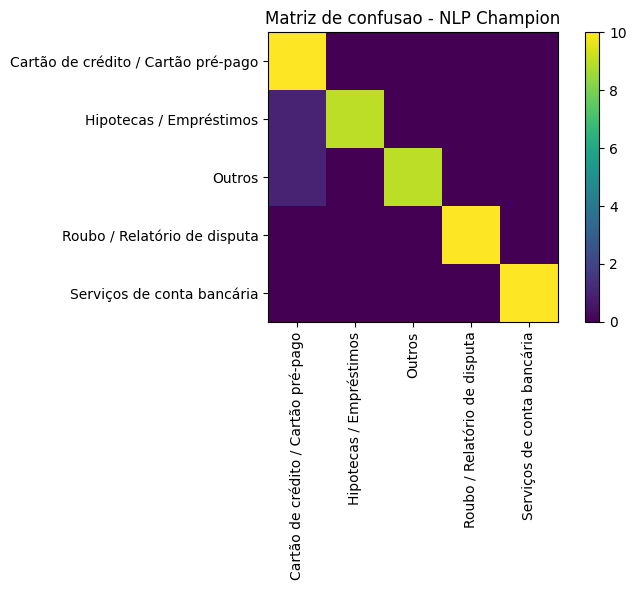

In [13]:
# Imprime matriz de confusão do campeão no teste
cm = confusion_matrix(test_eval[target_col], y_test_pred, labels=LABELS)
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Matriz de confusao - {champion_name}")
plt.xticks(np.arange(len(LABELS)), LABELS, rotation=90)
plt.yticks(np.arange(len(LABELS)), LABELS)
plt.colorbar()
plt.tight_layout()
plt.show()


## Comparacao final no TESTE: NLP vs Prompt vs RAG

In [14]:
# Comparação final no TESTE: NLP vs Prompt vs RAG
final_rows = []

# Melhor baseline NLP treinado neste notebook
pred_base_test = best_baseline.predict(test_df["text_clean"])
f1_base_test = weighted_f1(test_df[target_col], pred_base_test)
final_rows.append((f"NLP Baseline ({best_baseline_name})", f1_base_test))

# Champion da disciplina NLP - se disponível
if nlp_champion_f1_test is not None:
    final_rows.append(("NLP Champion", nlp_champion_f1_test))

if RUN_LLM:
    test_for_llm = test_df.copy()
    if DEV_MODE and len(test_for_llm) > LLM_MAX_TEST_SAMPLES_DEV:
        test_for_llm = test_for_llm.sample(n=LLM_MAX_TEST_SAMPLES_DEV, random_state=SEED)

    pred_prompt_test, inv_prompt_test = predict_llm_prompt(test_for_llm, temperature=0.0)
    f1_prompt_test = weighted_f1(test_for_llm[target_col], pred_prompt_test)
    final_rows.append(("Prompt Engineering (few-shot)", f1_prompt_test))

    pred_rag_test, inv_rag_test = predict_llm_rag(test_for_llm, k=RAG_TOP_K, temperature=0.0)
    f1_rag_test = weighted_f1(test_for_llm[target_col], pred_rag_test)
    final_rows.append((f"Prompt + RAG (k={RAG_TOP_K})", f1_rag_test))

final_report_df = pd.DataFrame(final_rows, columns=["etapa", "f1_weighted_test"]).sort_values("f1_weighted_test", ascending=False)
display(final_report_df)

# Resumo final
print("\nResumo da entrega")
print("- Metrica oficial: F1 weighted")
print(f"- Amostra final: {len(final_subset)} linhas (50 por classe)")
print(f"- Split sem vazamento: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
print(f"- Melhor resultado no teste: {final_report_df.iloc[0]['etapa']} -> {final_report_df.iloc[0]['f1_weighted_test']:.4f}")


LLM + RAG (k=4): 100%|██████████| 50/50 [01:09<00:00,  1.39s/it]


,etapa,f1_weighted_test
1,NLP Champion,0.960766
0,NLP Baseline (TFIDF + LinearSVC),0.710111
3,Prompt + RAG (k=4),0.185714
2,Prompt Engineering (few-shot),0.135632



Resumo da entrega
- Metrica oficial: F1 weighted
- Amostra final: 250 linhas (50 por classe)
- Split sem vazamento: train=150, val=50, test=50
- Melhor resultado no teste: NLP Champion -> 0.9608


## Atividade 2 (Extra)

Esta é uma atividade extra que poderá recuperar até 2 pontos na nota final do trabalho.

1. Faça um fine-tuning de um modelo de LLM para gerar um classificador de assuntos

2. Compare os resultados obtidos em cada etapa deste trabalho e também com relação aos resultados obtidos na disciplina de NLP.

In [15]:
!pip -q install -U transformers datasets accelerate peft bitsandbytes matplotlib
print("Dependências OK")

Dependências OK


In [16]:
import os, torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from transformers import set_seed
from datasets import Dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

set_seed(SEED)

print("CUDA disponível:", torch.cuda.is_available())
torch.manual_seed(SEED)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA disponível: True
GPU: NVIDIA GeForce RTX 4090


## Carregar modelo base para Fine-Tuning (LoRA)


In [17]:
FT_MODEL_CANDIDATES = [
    "mistralai/Mistral-7B-Instruct-v0.2",
    "microsoft/phi-2",
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
]

use_4bit = torch.cuda.is_available()
bnb_config = None
if use_4bit:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float16,
    )


def load_ft_model():
    errors = {}
    for model_id in FT_MODEL_CANDIDATES:
        try:
            print(f"Tentando carregar: {model_id}")
            tok = AutoTokenizer.from_pretrained(model_id, use_fast=True)
            if tok.pad_token is None:
                tok.pad_token = tok.eos_token

            kwargs = {"device_map": "auto"} if torch.cuda.is_available() else {}
            if use_4bit and bnb_config is not None:
                kwargs["quantization_config"] = bnb_config

            mdl = AutoModelForCausalLM.from_pretrained(model_id, **kwargs)
            mdl.config.use_cache = False
            print(f"Modelo carregado com sucesso: {model_id}")
            return model_id, tok, mdl
        except Exception as exc:
            errors[model_id] = repr(exc)
            print(f"Falhou: {model_id}")

    raise RuntimeError(f"Nenhum modelo foi carregado. Erros: {errors}")

FT_MODEL_ID, ft_tokenizer, ft_base_model = load_ft_model()
print("Modelo selecionado para fine-tuning:", FT_MODEL_ID)


Tentando carregar: mistralai/Mistral-7B-Instruct-v0.2


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Modelo carregado com sucesso: mistralai/Mistral-7B-Instruct-v0.2
Modelo selecionado para fine-tuning: mistralai/Mistral-7B-Instruct-v0.2


## Preparar dataset supervisionado (instrução -> classe)


In [18]:
def build_train_text(row):
    labels_str = ", ".join([f'"{x}"' for x in LABELS])
    return f"""Tarefa: classificar o assunto de um chamado da QuantumFinance.

Regras:
1) Escolha exatamente uma classe da lista permitida.
2) Responda APENAS em JSON válido.

Classes permitidas: [{labels_str}]

Chamado:
{row['text_clean']}

Saída esperada:
{{"classe": "{row[target_col]}"}}"""

ft_train_frame = train_df[["text_clean", target_col]].copy()

if DEV_MODE:
    # Em modo de desenvolvimento, reduz o treino para acelerar iterações.
    ft_train_frame = (
        ft_train_frame.groupby(target_col, group_keys=False)
        .apply(lambda x: x.sample(n=min(12, len(x)), random_state=SEED))
        .reset_index(drop=True)
    )

ft_train_frame["text"] = ft_train_frame.apply(build_train_text, axis=1)
ft_ds = Dataset.from_pandas(ft_train_frame[["text"]], preserve_index=False)
print("Registros de treino para FT:", len(ft_ds))
print("Amostra de treino FT:\n")
print(ft_ds[0]["text"][:800])


Registros de treino para FT: 150
Amostra de treino FT:

Tarefa: classificar o assunto de um chamado da QuantumFinance.

Regras:
1) Escolha exatamente uma classe da lista permitida.
2) Responda APENAS em JSON válido.

Classes permitidas: ["Cartão de crédito / Cartão pré-pago", "Hipotecas / Empréstimos", "Outros", "Roubo / Relatório de disputa", "Serviços de conta bancária"]

Chamado:
nao consigo fechar contas bancarias no chase bank, que foram usadas pelo meu ex -marido para transferir fundos dessas contas por cerca de uma decada. alem disso, o cartao de assinatura foi alterado e um carimbo com o bank one xxxx xxxx cash control foi colocado no cartao muito tempo depois que eu o abri. meus cheques do seguro social xxxx para mim, meu filho entao menor foi colocado em contas bancarias que meu ex -marido controlava com enderecos que eu nao consegui 


## Tokenização e configuração LoRA


In [19]:
def tokenize_batch(batch):
    return ft_tokenizer(batch["text"], truncation=True, max_length=512)

tokenized_ft = ft_ds.map(tokenize_batch, batched=True, remove_columns=ft_ds.column_names)
tokenized_ft.set_format(type="torch", columns=["input_ids", "attention_mask"])

# Identifica módulos compatíveis no modelo carregado para aplicar LoRA.
def infer_lora_targets(model):
    preferred = ["q_proj", "k_proj", "v_proj", "o_proj", "query_key_value"]
    names = set()
    for n, _ in model.named_modules():
        tail = n.split(".")[-1]
        if tail in preferred:
            names.add(tail)
    if names:
        return sorted(names)
    return ["q_proj", "v_proj"]

lora_targets = infer_lora_targets(ft_base_model)
print("Módulos LoRA:", lora_targets)

if use_4bit:
    ft_base_model = prepare_model_for_kbit_training(ft_base_model)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=lora_targets,
)

ft_model = get_peft_model(ft_base_model, lora_config)
ft_model.print_trainable_parameters()


Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Módulos LoRA: ['k_proj', 'o_proj', 'q_proj', 'v_proj']
trainable params: 6,815,744 || all params: 7,248,547,840 || trainable%: 0.0940


## Treinamento do modelo ajustado


In [ ]:
ft_output_dir = "outputs_lora_classificador_assuntos"

train_args = TrainingArguments(
    output_dir=ft_output_dir,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    num_train_epochs=6,
    logging_steps=50,
    save_strategy="epoch",
    optim="paged_adamw_8bit" if torch.cuda.is_available() else "adamw_torch",
    lr_scheduler_type="cosine",
    warmup_ratio=0.08,
    weight_decay=0.01,
    max_grad_norm=1.0,
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    report_to="none",
    seed=SEED,
    data_seed=SEED,
)

collator = DataCollatorForLanguageModeling(tokenizer=ft_tokenizer, mlm=False)

ft_trainer = Trainer(
    model=ft_model,
    args=train_args,
    train_dataset=tokenized_ft,
    data_collator=collator,
)

ft_train_result = ft_trainer.train()
print("Treinamento finalizado.")
print(ft_train_result)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
50,1.650368
100,1.227681


Treinamento finalizado.
TrainOutput(global_step=114, training_loss=1.4093975435223496, metrics={'train_runtime': 253.6091, 'train_samples_per_second': 3.549, 'train_steps_per_second': 0.45, 'total_flos': 1.639507712753664e+16, 'train_loss': 1.4093975435223496, 'epoch': 6.0})


## Inferência e avaliação do modelo Fine-Tuned (F1 weighted no TESTE)


In [21]:
def build_infer_prompt(text: str) -> str:
    labels_str = ", ".join([f'"{x}"' for x in LABELS])
    return f"""Tarefa: classificar o assunto de um chamado da QuantumFinance.

Regras:
1) Escolha exatamente uma classe da lista permitida.
2) Responda APENAS em JSON válido.

Classes permitidas: [{labels_str}]

Chamado:
{text}

Saída esperada:
{{"classe": "<uma classe permitida>"}}"""


def predict_finetuned(frame: pd.DataFrame):
    preds = []
    invalid = 0
    device = next(ft_model.parameters()).device

    ft_model.eval()
    for txt in tqdm(frame["text_clean"].tolist(), desc="Fine-Tuned LLM"):
        prompt = build_infer_prompt(txt)
        inputs = ft_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)

        with torch.no_grad():
            out = ft_model.generate(
                **inputs,
                max_new_tokens=40,
                do_sample=False,
                eos_token_id=ft_tokenizer.eos_token_id,
                pad_token_id=ft_tokenizer.eos_token_id,
            )

        gen_tokens = out[0][inputs["input_ids"].shape[1]:]
        gen_text = ft_tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

        label = parse_label_from_response(gen_text, LABELS)
        if label is None:
            invalid += 1
            raw = ft_tokenizer.decode(out[0], skip_special_tokens=True)
            label = parse_label_from_response(raw, LABELS)

        if label is None:
            invalid += 1
            label = DEFAULT_LABEL

        preds.append(label)

    return preds, invalid

ft_test_eval = test_df.copy()
if DEV_MODE and len(ft_test_eval) > LLM_MAX_TEST_SAMPLES_DEV:
    ft_test_eval = ft_test_eval.sample(n=LLM_MAX_TEST_SAMPLES_DEV, random_state=SEED)

ft_test_pred, ft_invalid_test = predict_finetuned(ft_test_eval)
ft_f1_test = weighted_f1(ft_test_eval[target_col], ft_test_pred)

print(f"F1 weighted no TESTE (Fine-Tuned LLM): {ft_f1_test:.4f}")
print("Respostas inválidas (fallback):", ft_invalid_test)
print("\nClassification report (Fine-Tuned):")
print(classification_report(ft_test_eval[target_col], ft_test_pred, labels=LABELS))


Fine-Tuned LLM: 100%|██████████| 50/50 [00:58<00:00,  1.16s/it]

F1 weighted no TESTE (Fine-Tuned LLM): 0.3290
Respostas inválidas (fallback): 14

Classification report (Fine-Tuned):
                                     precision    recall  f1-score   support

Cartão de crédito / Cartão pré-pago       0.22      0.60      0.32        10
            Hipotecas / Empréstimos       0.50      0.50      0.50        10
                             Outros       0.33      0.10      0.15        10
       Roubo / Relatório de disputa       1.00      0.20      0.33        10
         Serviços de conta bancária       0.38      0.30      0.33        10

                           accuracy                           0.34        50
                          macro avg       0.49      0.34      0.33        50
                       weighted avg       0.49      0.34      0.33        50



## Comparação consolidada: Parte 1 + Fine-Tuning + disciplina NLP


In [22]:
import re

nlp_notebook_path = Path("trabalho_final_NLP.ipynb")


def extract_nlp_notebook_metrics(nb_path: Path):
    if not nb_path.exists():
        return {}

    nb = json.loads(nb_path.read_text())
    text_blob = []

    for cell in nb.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        for out in cell.get("outputs", []):
            if "text" in out:
                text_blob.append("".join(out["text"]))
            elif "data" in out and "text/plain" in out["data"]:
                raw = out["data"]["text/plain"]
                text_blob.append("".join(raw) if isinstance(raw, list) else str(raw))

    merged = "\n".join(text_blob)

    patterns = {
        "NLP Baseline (disciplina NLP)": r"F1 Score:\s*([0-9]*\.?[0-9]+)",
        "NLP TF-IDF + LinearSVC (disciplina NLP)": r"F1 Score\s*-\s*TF-IDF \+ LinearSVC:\s*([0-9]*\.?[0-9]+)",
        "NLP Word2Vec + LogisticRegression (disciplina NLP)": r"F1 Score \(weighted\)\s*-\s*Word2Vec .*?:\s*([0-9]*\.?[0-9]+)",
    }

    out = {}
    for name, pat in patterns.items():
        m = re.search(pat, merged, re.IGNORECASE)
        if m:
            out[name] = float(m.group(1))

    # Último F1 Score tende a ser o campeão final no notebook de NLP.
    all_f1 = re.findall(r"F1 Score:\s*([0-9]*\.?[0-9]+)", merged, flags=re.IGNORECASE)
    if all_f1:
        out["NLP Campeão Final (disciplina NLP)"] = float(all_f1[-1])

    return out

comparison_rows = []

if "final_report_df" in globals():
    for _, row in final_report_df.iterrows():
        comparison_rows.append((f"GenerativeAI - {row['etapa']}", float(row["f1_weighted_test"]), "Parte 1"))

comparison_rows.append(("GenerativeAI - Fine-Tuned LLM", float(ft_f1_test), "Parte 2"))

if "nlp_champion_f1_test" in globals() and nlp_champion_f1_test is not None:
    comparison_rows.append(("GenerativeAI - NLP Champion carregado (.joblib)", float(nlp_champion_f1_test), "Parte 1 / NLP"))

nlp_metrics_from_notebook = extract_nlp_notebook_metrics(nlp_notebook_path)
for name, score in nlp_metrics_from_notebook.items():
    comparison_rows.append((name, float(score), "Disciplina NLP"))

comparison_df = pd.DataFrame(comparison_rows, columns=["etapa", "f1_weighted_test", "origem"])
comparison_df = comparison_df.drop_duplicates(subset=["etapa"], keep="last")
comparison_df = comparison_df.sort_values("f1_weighted_test", ascending=False).reset_index(drop=True)

display(comparison_df)

print("\nResumo comparativo final")
print(f"Melhor resultado consolidado: {comparison_df.iloc[0]['etapa']} -> {comparison_df.iloc[0]['f1_weighted_test']:.4f}")
print("Observação: os resultados da disciplina NLP foram extraídos automaticamente das saídas salvas no notebook trabalho_final_NLP.ipynb.")


,etapa,f1_weighted_test,origem
0,GenerativeAI - NLP Champion,0.960766,Parte 1
1,GenerativeAI - NLP Champion carregado (.joblib),0.960766,Parte 1 / NLP
2,NLP Campeão Final (disciplina NLP),0.910628,Disciplina NLP
3,NLP TF-IDF + LinearSVC (disciplina NLP),0.908800,Disciplina NLP
4,NLP Baseline (disciplina NLP),0.887559,Disciplina NLP
5,GenerativeAI - NLP Baseline (TFIDF + LinearSVC),0.710111,Parte 1
6,NLP Word2Vec + LogisticRegression (disciplina ...,0.574649,Disciplina NLP
7,GenerativeAI - Fine-Tuned LLM,0.328967,Parte 2
8,GenerativeAI - Prompt + RAG (k=4),0.185714,Parte 1
9,GenerativeAI - Prompt Engineering (few-shot),0.135632,Parte 1



Resumo comparativo final
Melhor resultado consolidado: GenerativeAI - NLP Champion -> 0.9608
Observação: os resultados da disciplina NLP foram extraídos automaticamente das saídas salvas no notebook trabalho_final_NLP.ipynb.
